<a href="https://colab.research.google.com/github/surabhias23/AI_CardioVascular_Disease_Prediction/blob/main/CardioVascular_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [26]:
df = pd.read_csv("cardio_train (1).csv", sep=";") ##Load Dataset
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [27]:
df['age'] = df['age'] / 365  ##Convert age from days to years
df.isnull().sum() ## Check missing values
df = df[(df['ap_hi'] > df['ap_lo'])] ## Remove unrealistic blood pressure values
df = df.drop("id", axis=1) ##Remove ID column

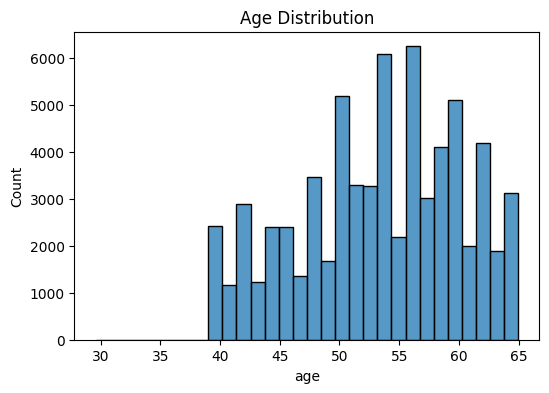

In [28]:
plt.figure(figsize=(6,4)) ## Distribution of Age
sns.histplot(df['age'], bins=30)
plt.title("Age Distribution")
plt.show()

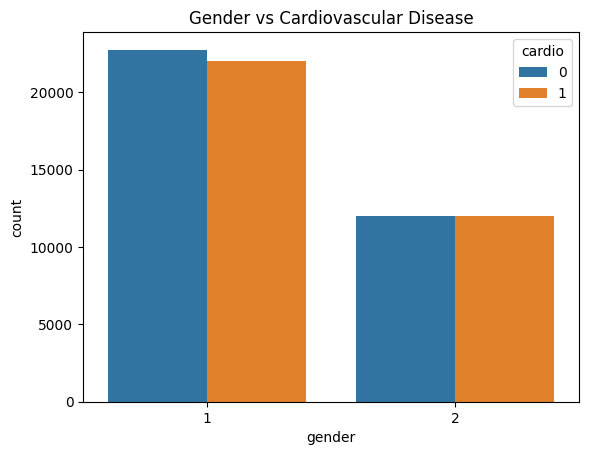

In [29]:
sns.countplot(x='gender', hue='cardio', data=df) ## Gender vs Heart Disease
plt.title("Gender vs Cardiovascular Disease")
plt.show()

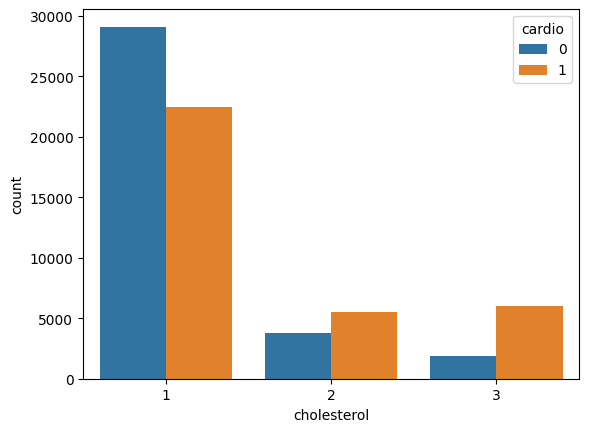

In [30]:
sns.countplot(x='cholesterol', hue='cardio', data=df) ## Cholesterol vs Heart Disease
plt.show()

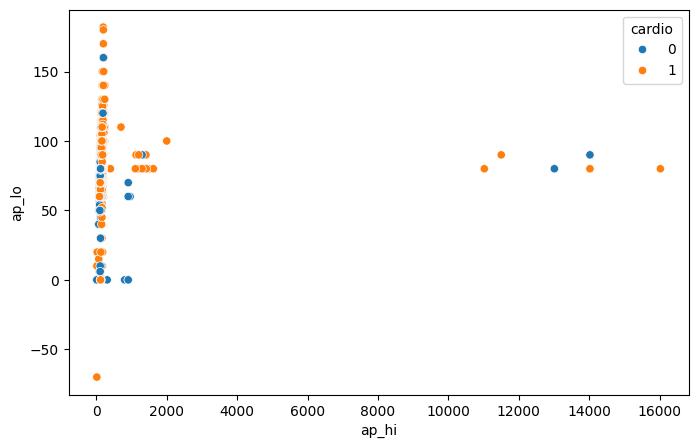

In [31]:
plt.figure(figsize=(8,5)) ## Blood Pressure Distribution
sns.scatterplot(x='ap_hi', y='ap_lo', hue='cardio', data=df)
plt.show()

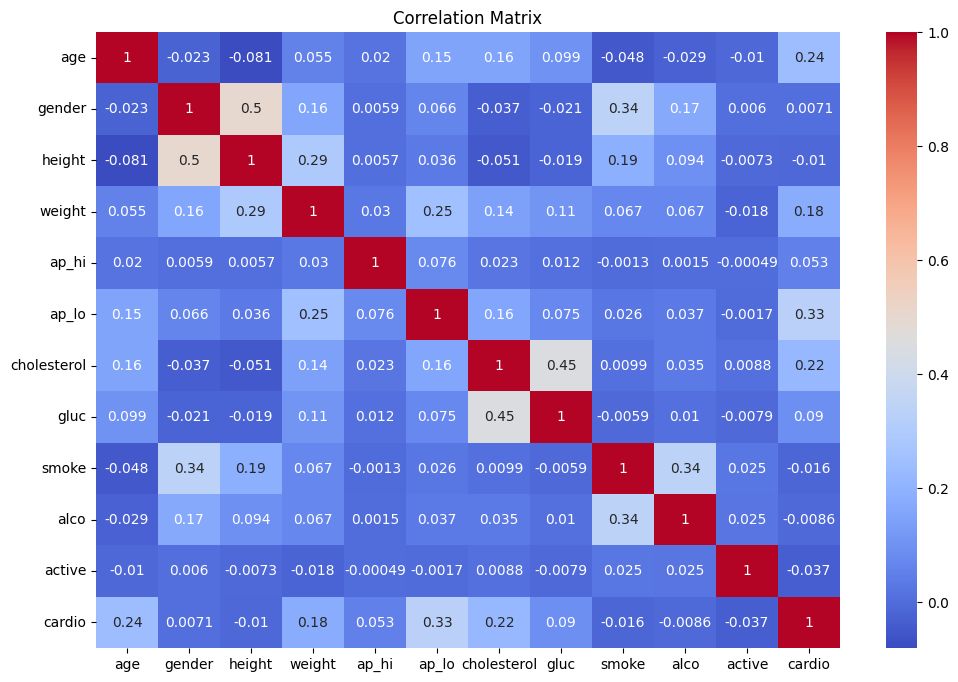

In [32]:
plt.figure(figsize=(12,8)) ## Correlation Matrix
corr = df.corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [33]:
X = df.drop("cardio", axis=1) ##Feature and Target Split
y = df["cardio"]

In [34]:
X_train, X_test, y_train, y_test = train_test_split( ##Train-Test Split
    X, y, test_size=0.2, random_state=42)

In [35]:
scaler = StandardScaler() ##Feature Scaling

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
## Training Models
lr = LogisticRegression() ##Logistic Regression
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

In [37]:
knn = KNeighborsClassifier(n_neighbors=5) ## KNN
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

In [38]:
svm = SVC() ## Support Vector Machine
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

In [39]:
rf = RandomForestClassifier(n_estimators=100) ## Random Forest
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

In [40]:
dt = DecisionTreeClassifier() ## Decision Tree
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

In [41]:
results = pd.DataFrame({ ##Accuracy Comparison
    "Model": ["Logistic Regression","KNN","SVM","Decision Tree","Random Forest"],
    "Accuracy":[lr_acc, knn_acc, svm_acc, dt_acc, rf_acc]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.724206
1                  KNN  0.667927
2                  SVM  0.727841
3        Decision Tree  0.642769
4        Random Forest  0.713881


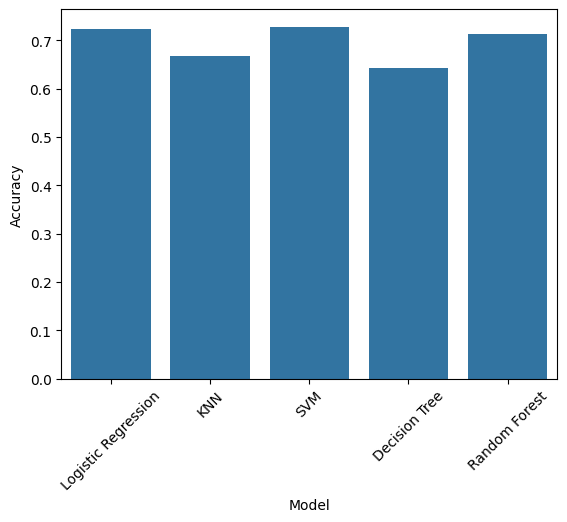

In [42]:
sns.barplot(x="Model", y="Accuracy", data=results) ## Visual Representation
plt.xticks(rotation=45)
plt.show()

In [43]:
print("Enter Patient Details")  ## Ask User for Input

age = float(input("Age (years): "))
gender = int(input("Gender (1=Female, 2=Male): "))
height = float(input("Height (cm): "))
weight = float(input("Weight (kg): "))
ap_hi = int(input("Systolic BP: "))
ap_lo = int(input("Diastolic BP: "))
cholesterol = int(input("Cholesterol (1=Normal,2=Above normal,3=Well above): "))
gluc = int(input("Glucose (1=Normal,2=Above normal,3=Well above): "))
smoke = int(input("Smoking (0=No,1=Yes): "))
alco = int(input("Alcohol (0=No,1=Yes): "))
active = int(input("Physical Activity (0=No,1=Yes): "))

Enter Patient Details
Age (years): 55
Gender (1=Female, 2=Male): 1
Height (cm): 160
Weight (kg): 70
Systolic BP: 130
Diastolic BP: 80
Cholesterol (1=Normal,2=Above normal,3=Well above): 1
Glucose (1=Normal,2=Above normal,3=Well above): 1
Smoking (0=No,1=Yes): 0
Alcohol (0=No,1=Yes): 0
Physical Activity (0=No,1=Yes): 1


In [46]:
user_data = np.array([[age, gender, height, weight, ## Predict Heart Disease
                       ap_hi, ap_lo, cholesterol,
                       gluc, smoke, alco, active]])

user_data = scaler.transform(user_data)
prediction = model.predict(user_data)

if prediction[0] == 1:
    print("High risk of Cardiovascular Disease")
else:
    print("Low risk of Cardiovascular Disease")

Low risk of Cardiovascular Disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
